In [ ]:
!wget -q https://raw.githubusercontent.com/Bangnyfe/PCA_Formative_1-Peer_Pair_20-/main/sas_2024_seasonA_production.csv -O sas_2024_seasonA_production.csv

### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

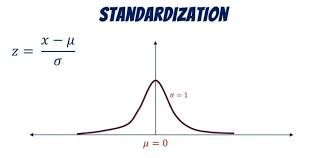


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data = np.loadtxt(
    'sas_2024_seasonA_production.csv',
    delimiter=',',
    dtype=str,
    skiprows=1,
    quotechar='"'
)

# Load the column names
column_names = np.loadtxt(
    'sas_2024_seasonA_production.csv',
    delimiter=',',
    dtype=str,
    max_rows=1,
    quotechar='"'
)
print("Shape:", data.shape)

Shape: (39330, 96)


In [ ]:
# Select the columns to use for PCA
selected_columns = [
    's1q9',        # Age
    's2q2',        # Plot area
    's2q3',        # Number of main crops
    's2q21',       # Total harvest
    's2q25',       # Quantity transformed
    's2q26',       # Quantity sold
    's2q29',       # Household consumption
    's2q34',       # Quantity used as seed
    's2q36',       # Quantity stored
    's2q39',       # Quantity lost
    'CropCategory' # Crop type grown (non-numeric -> needs encoding)
]

selected_indices = []
for column in selected_columns:
    index = np.where(column_names == column)[0][0]
    selected_indices.append(index)

numeric_data = data[:, selected_indices].copy()

In [ ]:
#Encode the non-numeric column (CropCategory)
crop_col_index = selected_columns.index('CropCategory')
crop_column = numeric_data[:, crop_col_index]
unique_crops, crop_codes = np.unique(crop_column, return_inverse=True)
numeric_data[:, crop_col_index] = crop_codes.astype(str)
print(f"Encoded {len(unique_crops)} crop categories into numeric codes 0-{len(unique_crops)-1}")

# Convert missing values to NaN
numeric_data[numeric_data == ''] = 'nan'
numeric_data[numeric_data == 'NA'] = 'nan'
numeric_data[numeric_data == 'NaN'] = 'nan'

# Convert text values to numbers
numeric_data = numeric_data.astype(float)

Encoded 21 crop categories into numeric codes 0-20


In [ ]:
# Replace missing values with the mean of each column
for i in range(numeric_data.shape[1]):
    column_mean = np.nanmean(numeric_data[:, i])

    numeric_data[np.isnan(numeric_data[:, i]), i] = column_mean

In [ ]:
# Step 1: Load and Standardize the data
mean = np.mean(numeric_data, axis=0)
std = np.std(numeric_data, axis=0)

standardized_data = (numeric_data - mean) / std

standardized_data[:5]

array([[ 0.92282611,  0.38543154, -1.46327621,  2.59202549, -0.03696402,
        -0.06586468, -0.04436336, -0.02273182, -0.03004271, -0.03471321,
        -0.14867308],
       [ 0.92282611,  2.1187514 , -1.46327621, 14.48424604, -0.03696402,
        -0.06586468, -0.04436336, -0.02273182, -0.03004271, -0.03471321,
        -0.14867308],
       [ 0.92282611,  0.01973599, -1.46327621,  0.23998008, -0.03696402,
        -0.06586468, -0.04436336, -0.02273182, -0.03004271, -0.03471321,
        -0.14867308],
       [ 0.92282611, -0.05736307, -1.46327621, -0.05638644, -0.03696402,
        -0.06586468, -0.04436336,  0.07786577, -0.03004271, -0.03471321,
        -0.14867308],
       [ 0.92282611, -0.0268244 , -0.78343434, -0.05540849, -0.03696402,
        -0.06586468, -0.04436336,  0.07786577, -0.03004271, -0.03471321,
        -0.14867308]])

### Step 2: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [ ]:
# Step 2: Calculate the Covariance Matrix
covariance_matrix = np.cov(standardized_data, rowvar=False)

covariance_matrix

array([[ 1.00002543e+00,  4.18541091e-03,  9.05570769e-02,
         1.72702799e-03,  2.12251018e-02,  1.64352414e-03,
        -1.25263359e-03,  8.79475812e-03,  1.06902130e-02,
         5.73590736e-04, -3.18599755e-02],
       [ 4.18541091e-03,  1.00002543e+00, -6.74658147e-02,
         9.34809131e-01,  4.19535425e-02,  7.50004927e-01,
         5.88741190e-01,  5.50663321e-03,  3.86010519e-03,
         3.97124399e-01,  3.92664741e-02],
       [ 9.05570769e-02, -6.74658147e-02,  1.00002543e+00,
        -6.58261994e-02, -2.43317449e-02, -7.08230399e-02,
        -4.60590851e-02, -2.29664997e-02, -2.18789527e-02,
        -3.76305166e-02, -1.56713718e-01],
       [ 1.72702799e-03,  9.34809131e-01, -6.58261994e-02,
         1.00002543e+00,  5.11446641e-02,  7.95076125e-01,
         6.46059510e-01,  2.13464648e-02,  5.03861517e-03,
         3.42610083e-01,  3.73891150e-02],
       [ 2.12251018e-02,  4.19535425e-02, -2.43317449e-02,
         5.11446641e-02,  1.00002543e+00,  9.42241343e-02,
  

We calculate the covariance matrix so we can see how the different features in the dataset change in relation to each other. It helps us identify which variables tend to move together and which ones behave differently. PCA then uses this matrix to find the eigenvalues and eigenvectors that form the principal components. This is what allows us to reduce the number of features while still keeping most of the important information in the data.

### Step 3: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [ ]:
# Step 3: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)
print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

Eigenvalues:
[3.44571225 0.05820107 0.18736124 0.47527725 1.19014492 0.82442404
 0.8431507  0.95670177 1.02068994 1.00133535 0.99728116]

Eigenvectors:
[[ 7.57097497e-04  2.12153815e-03 -2.74364578e-04 -7.76791592e-03
  -4.11835321e-01  2.90454225e-01 -5.71468944e-02 -7.09467945e-01
  -4.87970207e-01 -3.51317160e-02 -1.68208841e-03]
 [-4.92789818e-01 -6.59817476e-01 -2.38656892e-01  5.12210701e-01
  -2.97278226e-02  8.08085134e-03  2.40021895e-02 -4.84197594e-03
   2.35811087e-02 -1.58908373e-02  1.11802980e-02]
 [ 5.64633373e-02 -2.56264175e-03  8.40198507e-03  1.32834216e-02
  -6.71688730e-01 -7.06541982e-01  1.93383120e-01  2.84607281e-02
   8.39717826e-02 -2.58310459e-02  1.62914562e-02]
 [-5.02334765e-01  7.40183869e-01 -8.94529273e-02  4.20253062e-01
  -3.20975065e-02  2.75731574e-02  1.13545427e-01  1.30217626e-02
   8.19532159e-03 -1.54307512e-02 -3.90260529e-03]
 [-4.32017618e-02  7.25105056e-04 -6.24432767e-02 -4.96487194e-03
   2.17112006e-02 -1.41572631e-01 -9.98507224e-02 

### Step 4: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [ ]:
# Step 4: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]
sorted_eigenvectors

array([[ 7.57097497e-04, -4.11835321e-01, -4.87970207e-01,
        -3.51317160e-02, -1.68208841e-03, -7.09467945e-01,
        -5.71468944e-02,  2.90454225e-01, -7.76791592e-03,
        -2.74364578e-04,  2.12153815e-03],
       [-4.92789818e-01, -2.97278226e-02,  2.35811087e-02,
        -1.58908373e-02,  1.11802980e-02, -4.84197594e-03,
         2.40021895e-02,  8.08085134e-03,  5.12210701e-01,
        -2.38656892e-01, -6.59817476e-01],
       [ 5.64633373e-02, -6.71688730e-01,  8.39717826e-02,
        -2.58310459e-02,  1.62914562e-02,  2.84607281e-02,
         1.93383120e-01, -7.06541982e-01,  1.32834216e-02,
         8.40198507e-03, -2.56264175e-03],
       [-5.02334765e-01, -3.20975065e-02,  8.19532159e-03,
        -1.54307512e-02, -3.90260529e-03,  1.30217626e-02,
         1.13545427e-01,  2.75731574e-02,  4.20253062e-01,
        -8.94529273e-02,  7.40183869e-01],
       [-4.32017618e-02,  2.17112006e-02, -6.28518993e-01,
         6.40180330e-01, -2.10246498e-01,  3.38606479e-01,
  

### Step 5: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [ ]:
# Step 5: Project Data onto Principal Components
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)
print("Explained variance per PC:", np.round(explained_variance_ratio, 3))
print("Cumulative variance:", np.round(cumulative_variance, 3))

variance_threshold = 0.95   # keep enough PCs to explain >= 95% of variance
num_components = np.argmax(cumulative_variance >= variance_threshold) + 1
print(f"Components needed for {variance_threshold*100:.0f}% variance: {num_components}")

top_eigenvectors = sorted_eigenvectors[:, :num_components]
reduced_data = standardized_data @ top_eigenvectors
reduced_data[:5]

Explained variance per PC: [0.313 0.108 0.093 0.091 0.091 0.087 0.077 0.075 0.043 0.017 0.005]
Cumulative variance: [0.313 0.421 0.514 0.605 0.696 0.783 0.86  0.934 0.978 0.995 1.   ]
Components needed for 95% variance: 9


array([[-1.50589258e+00,  4.17392950e-01, -4.83887067e-01,
        -4.48216597e-02, -3.42449784e-02, -6.11492036e-01,
        -4.73657987e-02,  1.47394694e+00,  1.31325024e+00],
       [-8.33393078e+00, -1.58455021e-02, -3.45552890e-01,
        -2.55871461e-01, -6.12765885e-02, -4.65027057e-01,
         1.34454493e+00,  1.81585971e+00,  7.19881734e+00],
       [-1.44167360e-01,  5.03759076e-01, -5.11786342e-01,
        -2.71662363e-03, -2.91544588e-02, -6.40349124e-01,
        -3.23207293e-01,  1.40613849e+00,  1.37482784e-01],
       [ 4.17533908e-02,  5.22900056e-01, -5.51943376e-01,
        -6.50465039e-02, -8.91828837e-02, -6.23725821e-01,
        -3.58515990e-01,  1.38796463e+00, -2.76423318e-02],
       [ 6.45991208e-02,  6.53186999e-02, -4.94127692e-01,
        -8.31079060e-02, -7.77696549e-02, -6.04512159e-01,
        -2.26202012e-01,  9.07901554e-01, -2.55847956e-03]])

### Step 6: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [ ]:
# Step 6: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (39330, 9)


array([[-1.50589258e+00,  4.17392950e-01, -4.83887067e-01,
        -4.48216597e-02, -3.42449784e-02, -6.11492036e-01,
        -4.73657987e-02,  1.47394694e+00,  1.31325024e+00],
       [-8.33393078e+00, -1.58455021e-02, -3.45552890e-01,
        -2.55871461e-01, -6.12765885e-02, -4.65027057e-01,
         1.34454493e+00,  1.81585971e+00,  7.19881734e+00],
       [-1.44167360e-01,  5.03759076e-01, -5.11786342e-01,
        -2.71662363e-03, -2.91544588e-02, -6.40349124e-01,
        -3.23207293e-01,  1.40613849e+00,  1.37482784e-01],
       [ 4.17533908e-02,  5.22900056e-01, -5.51943376e-01,
        -6.50465039e-02, -8.91828837e-02, -6.23725821e-01,
        -3.58515990e-01,  1.38796463e+00, -2.76423318e-02],
       [ 6.45991208e-02,  6.53186999e-02, -4.94127692e-01,
        -8.31079060e-02, -7.77696549e-02, -6.04512159e-01,
        -2.26202012e-01,  9.07901554e-01, -2.55847956e-03]])

### Step 7: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

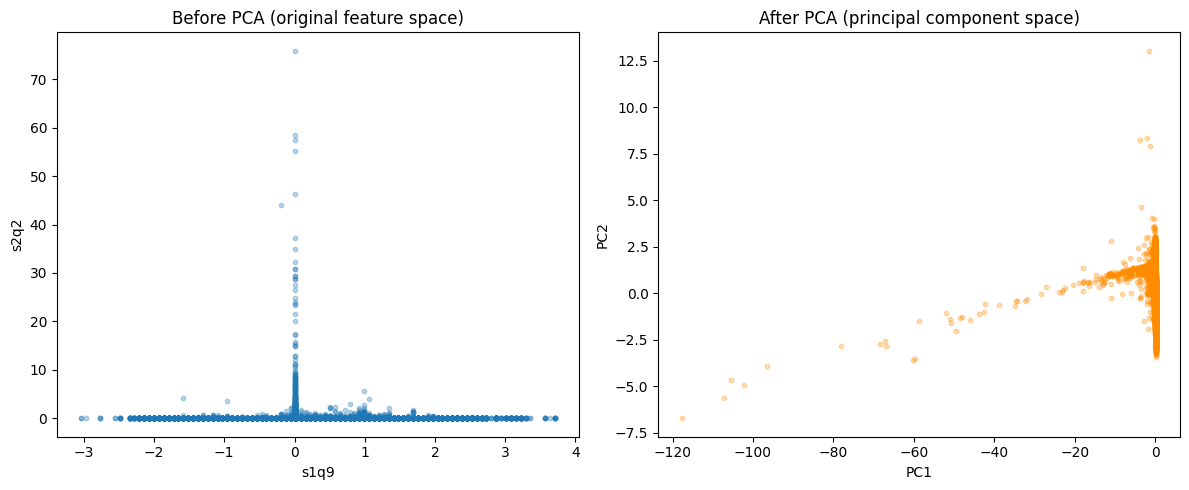

In [ ]:
# Step 7: Visualize Before and After PCA

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot original data (first two features for simplicity)
axes[0].scatter(standardized_data[:, 0], standardized_data[:, 1], alpha=0.3, s=10)
axes[0].set_xlabel(selected_columns[0])
axes[0].set_ylabel(selected_columns[1])
axes[0].set_title("Before PCA (original feature space)")

# Plot reduced data after PCA (PC1 vs PC2)
axes[1].scatter(reduced_data[:, 0], reduced_data[:, 1], alpha=0.3, s=10, color='darkorange')
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("After PCA (principal component space)")

plt.tight_layout()
plt.show()

Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?


1. The "before" plot (Age vs Plot area) is a dense, boxy cloud with a few extreme outliers, since these two raw features are barely correlated. The "after" plot (PC1 vs PC2) stretches the same points further along PC1, the direction of greatest variance, while PC2 stays comparatively narrow.

2. We dynamically selected components using a 95% cumulative explained-variance threshold, which kept 9 of the 11 components. Because most of our variables (age, plot area, crop count, crop type) are only weakly correlated with each other, very little variance is redundant, so a high threshold is needed to avoid discarding real information. The tradeoff: a lower threshold (e.g. 80%) would shrink the data to about 6 components, but at the cost of losing meaningful variation in the less-correlated variables.

3. Dropping the two lowest-variance components mostly discards fine detail in variables that move independently of the main harvest/sales cluster, such as crop type and quantity used as seed. This can blur household-level nuances relevant to food security and land-use pressure, even though the dominant economic-activity signal is well preserved in the retained components.